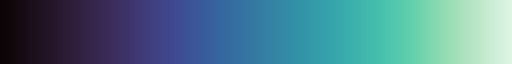

In [3]:
import numpy as np
from scipy.spatial import Delaunay
import pandas as pd
from itertools import combinations
import os
from scipy.stats import ecdf
from sklearn.decomposition import PCA
from astropy.table import Table as t
import glob
from scipy.stats import norm
from scipy.stats import gaussian_kde

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.tri as mtri
matplotlib.rcParams['figure.dpi'] = 360
# matplotlib.rcParams['text.usetex'] = True
# os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})
# plt.style.use('default')
cmap = sns.color_palette('mako', as_cmap=True)
cmap

### PDF Plot

In [4]:
base_url = './data/results/'
os.listdir = os.path.dirname(base_url)

In [5]:
pattern = os.path.join(base_url, 'rosette_*.csv')
files = sorted(glob.glob(pattern))
len(files)

20

In [ ]:
H_all = []
for fpath in files:
    print(fpath)
    df = pd.read_csv(fpath)
    # print(df['H'].describe())
    H_all.extend(df['H'].values)

H_all.sort()

In [10]:
pd.read_csv(f)

,TARGETID,r,type,p_void,p_sheet,p_filament,p_knot,H
0,39627794476435354,-0.555556,sheet,0.0,1.00,0.00,0.0,-0.000000
1,39627812579053607,0.027027,sheet,0.0,0.77,0.23,0.0,0.389006
2,39627806547645143,-0.210526,sheet,0.0,0.99,0.01,0.0,0.040397
3,39627812562277114,-0.125000,sheet,0.0,0.98,0.02,0.0,0.070720
4,39627788411471311,0.454545,filament,0.0,0.00,1.00,0.0,-0.000000
...,...,...,...,...,...,...,...,...
14123,39627740109871238,-0.529412,sheet,0.0,1.00,0.00,0.0,-0.000000
14124,39627734065878343,-0.655172,sheet,0.0,1.00,0.00,0.0,-0.000000
14125,39627734070067511,-0.142857,sheet,0.0,0.84,0.16,0.0,0.317155
14126,39627734061683240,-0.200000,sheet,0.0,0.98,0.02,0.0,0.070720


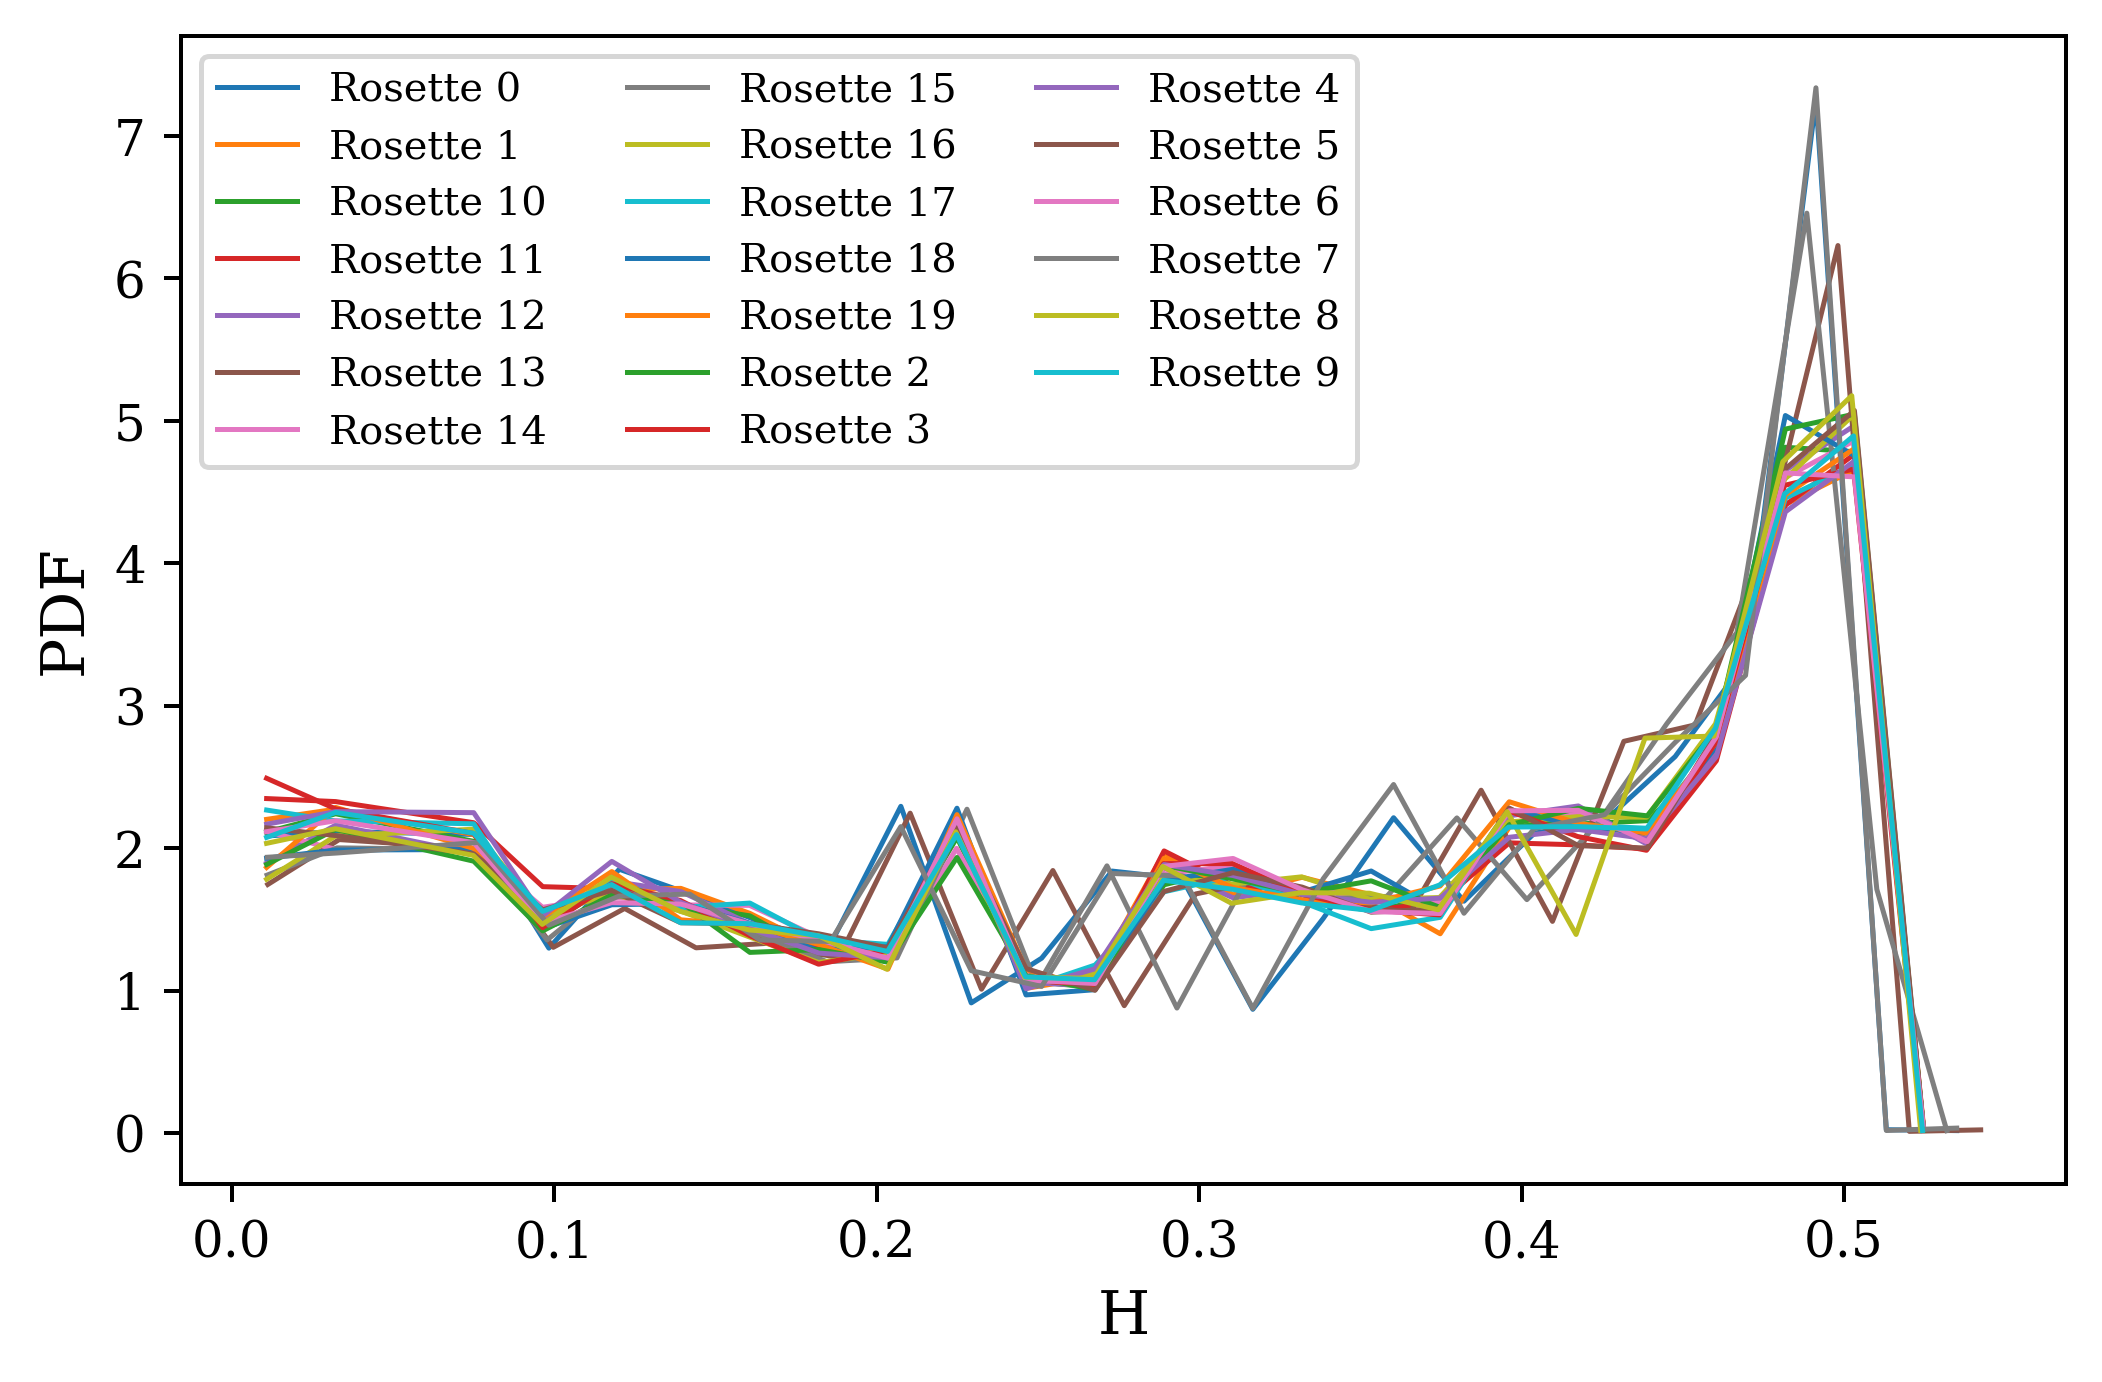

In [9]:
plt.figure(figsize=(6,4))

fns = sorted(glob.glob('data/results/rosette_*.csv'))
for f in fns:
    df = pd.read_csv(f)
    H = df['H'].values

    pdf, edges = np.histogram(H, bins=25, density=True)
    centers = 0.5*(edges[:-1] + edges[1:])
    rosette = f.split('/')[-1].split('_')[-1].split('.')[0]
    
    mask = pdf > 0
    
    plt.plot(centers[mask], pdf[mask], lw=1, label=f'Rosette {rosette}')
plt.xlabel('H')
plt.ylabel('PDF')
plt.legend(ncol=3, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

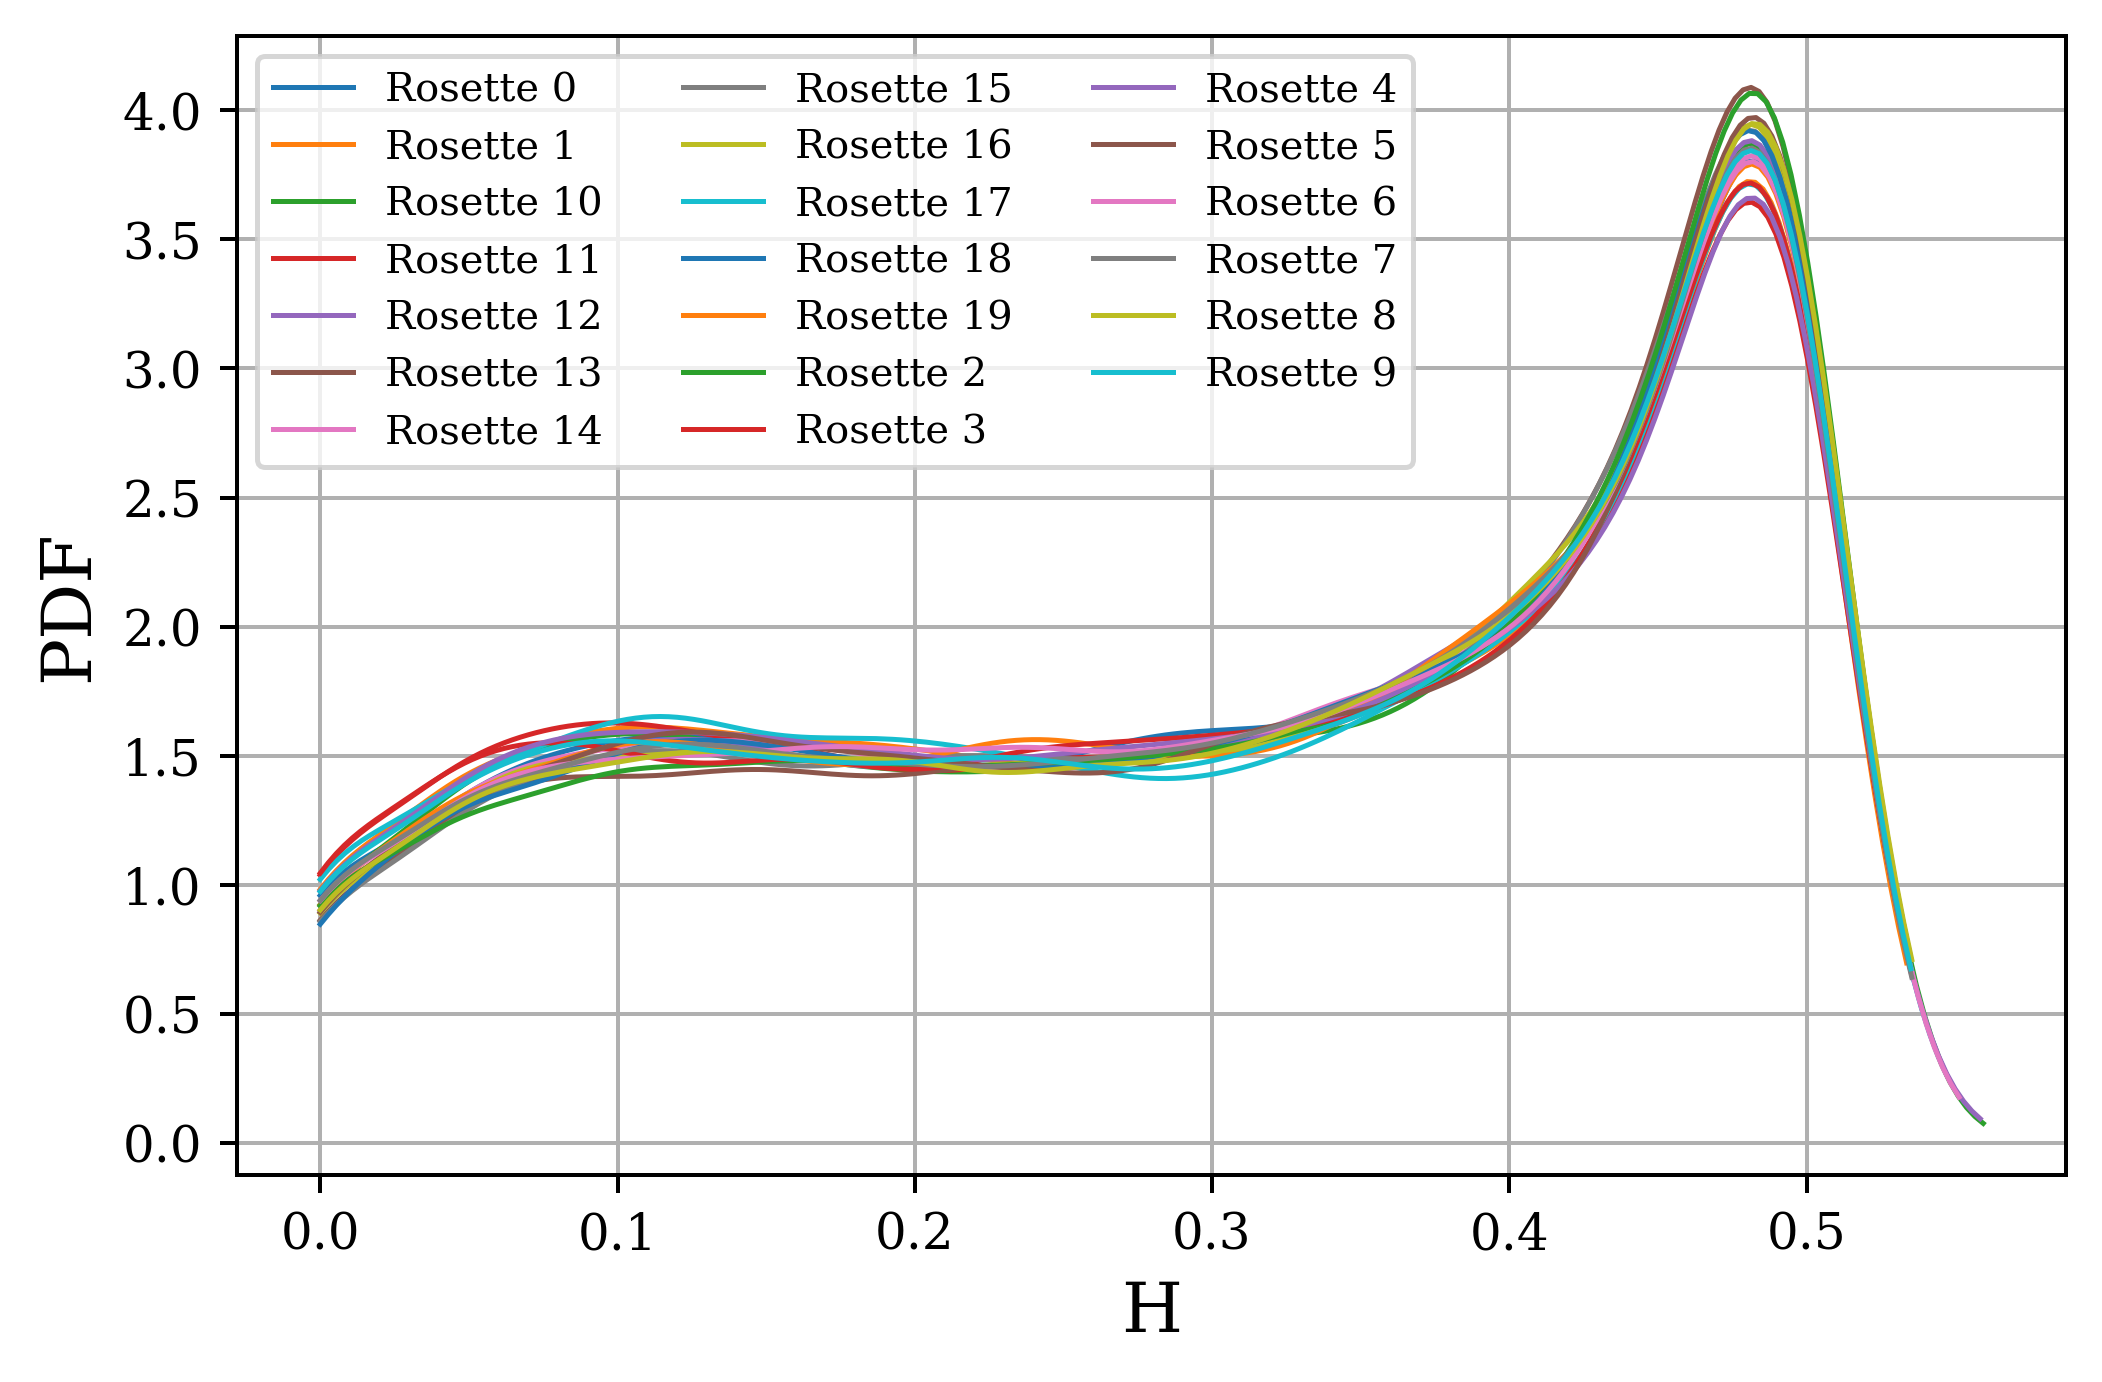

In [13]:
plt.figure(figsize=(6, 4))

fns = sorted(glob.glob('data/results/rosette_*.csv'))
for f in fns:
    df = pd.read_csv(f)
    H = df['H'].values

    kde = gaussian_kde(H)
    
    x_vals = np.linspace(min(H), max(H), 200)
    pdf_vals = kde(x_vals)

    rosette = f.split('/')[-1].split('_')[-1].split('.')[0]

    plt.plot(x_vals, pdf_vals, lw=1, label=f'Rosette {rosette}')

plt.xlabel('H', fontsize=14)
plt.ylabel('PDF', fontsize=14)
plt.legend(ncol=3, loc='upper left', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

--------

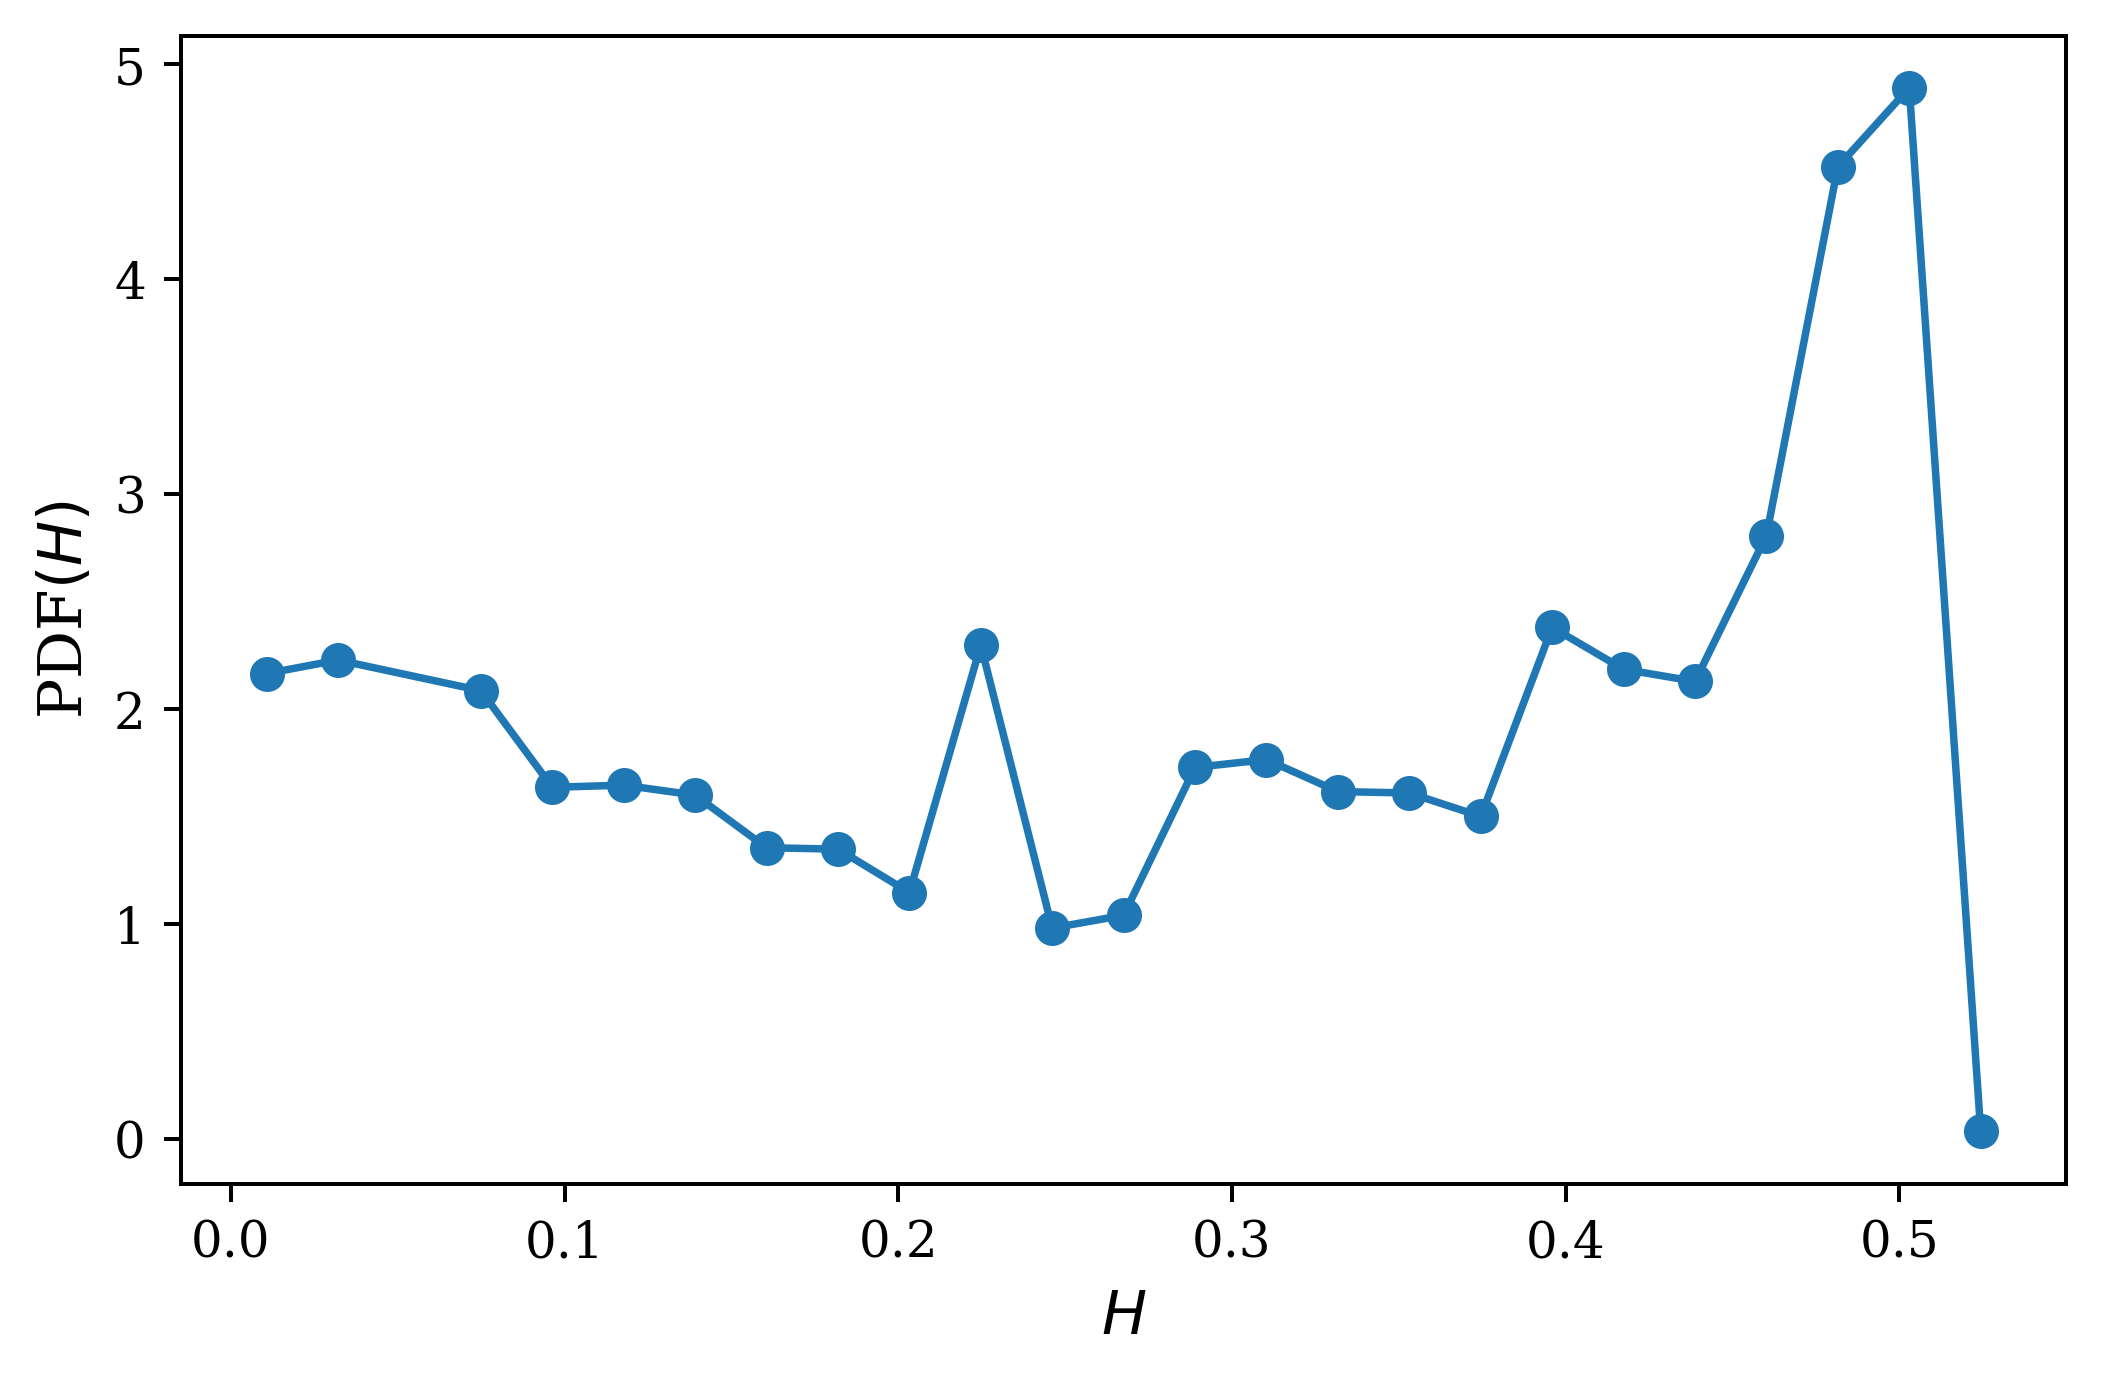

In [170]:
pdf, edges = np.histogram(H, bins=25, density=True)
centers = 0.5*(edges[:-1] + edges[1:])

plt.figure(figsize=(6,4))
plt.plot(centers[mask], pdf[mask], marker='o', linestyle='-')  # <–– fíjate: primero ‘centers’, luego ‘pdf’
plt.xlabel('$H$')
plt.ylabel('PDF$(H)$')
plt.tight_layout()
plt.show()